# HyperRAG V2 — Notebook 8: Combined Chunk, Ranking & LLM Analysis

**What this notebook does — end-to-end pipeline:**

```
Mixed question subset
  ├── graph-wins  : Simple EM=0, HyperRAG EM=1  (graph expansion adds value)
  └── both-pass   : Simple EM=1, HyperRAG EM=1  (control group — sanity check)
        ↓
Chunk each page  →  FAISS index  →  Retrieve top-k chunks per system
        ↓
PRE-LLM metrics per system  (Retrieval EM, F1, Supporting Recall, chunk breakdown)
        ↓
LLM answer generation
  ├── Local HuggingFace model  (Llama-3.2-3B or flan-t5)
  └── DeepSeek API             (deepseek-chat, openai-compatible)
        ↓
Generation EM / F1  →  Save JSON + CSV  →  Charts
```

| System | Retrieval | Context format |
|--------|-----------|----------------|
| Simple RAG | FAISS top-k chunks | plain text |
| HtmlRAG    | FAISS top-k chunks | cleaned HTML (structured) |
| HyperRAG   | FAISS top-k + 1-hop graph expansion | plain text |

**Prerequisites:** Run notebooks 01–04 first to build `data/corpus_001.json`,
`data/questions_001.json`, `data/results_simple_rag.json`, `data/results_htmlrag.json`,
`data/results_hyperrag.json`.

In [29]:
# =============================================================
# CONFIGURATION — edit these before running
# =============================================================

# ── Question subset ──────────────────────────────────────────
N_FAIL = 500    # 'graph-wins': Simple EM=0, HyperRAG EM=1
N_BOTH = 500   # 'both-pass' : Simple EM=1, HyperRAG EM=1 (control)

# ── Chunking & retrieval ─────────────────────────────────────
CHUNK_SIZE    = 512   # characters per chunk
CHUNK_OVERLAP = 64    # character overlap between adjacent chunks
K             = 8     # top-k chunks to retrieve per system
EXPAND_K      = 5     # HyperRAG only: extra neighbor chunks from graph

# ── Local LLM (HuggingFace) ──────────────────────────────────
USE_LOCAL_LLM = True
LOCAL_MODEL   = 'meta-llama/Llama-3.2-3B-Instruct'  # or 'google/flan-t5-base'
IS_CAUSAL_LM  = True   # True for Llama/TinyLlama, False for flan-t5

# ── DeepSeek API ─────────────────────────────────────────────
USE_DEEPSEEK   = True
DEEPSEEK_KEY   = 'sk-55c8107bea9d4b069a0ecd9b4ba9a948'   # <── paste your key here
DEEPSEEK_MODEL = 'deepseek-chat'            # or 'deepseek-reasoner' for R1

# ── Context & output ─────────────────────────────────────────
MAX_CTX_CHARS = 2500   # characters of context sent to LLM
SAVE_RESULTS  = True   # write JSON + CSV to data/llm_analysis/

# ── Print summary ────────────────────────────────────────────
print('=' * 58)
print('CONFIGURATION SUMMARY')
print('=' * 58)
print(f'  Subset    : {N_FAIL} graph-wins  +  {N_BOTH} both-pass  =  up to {N_FAIL+N_BOTH} questions')
print(f'  Chunks    : size={CHUNK_SIZE}  overlap={CHUNK_OVERLAP}')
print(f'  Retrieve  : k={K}  expand_k={EXPAND_K} (HyperRAG)')
print(f'  Local LLM : {LOCAL_MODEL if USE_LOCAL_LLM else "disabled"}')
print(f'  DeepSeek  : {"enabled — " + DEEPSEEK_MODEL if USE_DEEPSEEK else "disabled"}')
print(f'  Max ctx   : {MAX_CTX_CHARS} chars to LLM')
print('=' * 58)

CONFIGURATION SUMMARY
  Subset    : 500 graph-wins  +  500 both-pass  =  up to 1000 questions
  Chunks    : size=512  overlap=64
  Retrieve  : k=8  expand_k=5 (HyperRAG)
  Local LLM : meta-llama/Llama-3.2-3B-Instruct
  DeepSeek  : enabled — deepseek-chat
  Max ctx   : 2500 chars to LLM


In [2]:
import json, sys, re, string, csv
from pathlib import Path
from collections import Counter, defaultdict

import faiss
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Path setup ───────────────────────────────────────────────
if Path('utils.py').exists():
    BASE_DIR = Path('.')
elif Path('v2/utils.py').exists():
    BASE_DIR = Path('v2')
else:
    raise FileNotFoundError('utils.py not found. Run from v2/ or HyperRAG-M2/')

DATA_DIR   = BASE_DIR / 'data'
OUTPUT_DIR = DATA_DIR / 'llm_analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(BASE_DIR))
from utils import (
    embed_texts, build_index, retrieve,
    compute_em, compute_f1, compute_supporting_recall, clean_html
)

print(f'BASE_DIR   : {BASE_DIR.resolve()}')
print(f'OUTPUT_DIR : {OUTPUT_DIR.resolve()}')
print('All imports OK.')

W0430 22:14:41.343000 324708 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


BASE_DIR   : C:\Users\Admin\OneDrive\Desktop\AI-research assignment\HyperRAG-M2\v2
OUTPUT_DIR : C:\Users\Admin\OneDrive\Desktop\AI-research assignment\HyperRAG-M2\v2\data\llm_analysis
All imports OK.


In [3]:
# ── Load corpus and questions ────────────────────────────────
print('Loading corpus and questions...')
with open(DATA_DIR / 'corpus_001.json')    as f: corpus    = json.load(f)
with open(DATA_DIR / 'questions_001.json') as f: questions = json.load(f)

# ── Load prior retrieval results ─────────────────────────────
for fname in ['results_simple_rag.json', 'results_htmlrag.json', 'results_hyperrag.json']:
    if not (DATA_DIR / fname).exists():
        raise FileNotFoundError(f'{fname} missing — run notebooks 02, 03, 04 first.')

with open(DATA_DIR / 'results_simple_rag.json') as f: simple_results = json.load(f)
with open(DATA_DIR / 'results_htmlrag.json')    as f: html_results   = json.load(f)
with open(DATA_DIR / 'results_hyperrag.json')   as f: hyper_results  = json.load(f)

# ── Build per-question lookup dicts ──────────────────────────
simple_per_q = {r['id']: r for r in simple_results['per_question']}
html_per_q   = {r['id']: r for r in html_results['per_question']}
hyper_per_q  = {r['id']: r for r in hyper_results['per_question']}

print(f'Corpus    : {len(corpus):,} pages')
print(f'Questions : {len(questions):,}')
print()
print('Prior full-corpus retrieval results (for subset selection):')
print(f'  Simple RAG  — mean EM = {simple_results["mean_em"]:.3f}')
print(f'  HtmlRAG     — mean EM = {html_results["mean_em"]:.3f}')
print(f'  HyperRAG    — mean EM = {hyper_results["mean_em"]:.3f}')

Loading corpus and questions...
Corpus    : 9,999 pages
Questions : 5,329

Prior full-corpus retrieval results (for subset selection):
  Simple RAG  — mean EM = 0.682
  HtmlRAG     — mean EM = 0.706
  HyperRAG    — mean EM = 0.756


---
## Section 1 — Question Subset (Mixed)

We use **two groups** of questions:

| Group | Condition | Purpose |
|-------|-----------|------|
| `graph-wins` | Simple EM=0, HyperRAG EM=1 | Cases where graph expansion adds real value |
| `both-pass`  | Simple EM=1, HyperRAG EM=1 | Control group — both systems succeed |

Having both groups lets us see whether HyperRAG **preserves** performance on easy questions
while **gaining** on hard ones.

In [30]:
# ── Categorize all questions by EM pattern ───────────────────
fail_then_graph = []   # Simple=0, Hyper=1
both_pass       = []   # Simple=1, Hyper=1
both_fail       = []   # Simple=0, Hyper=0
graph_fails     = []   # Simple=1, Hyper=0 (edge case)

for q in questions:
    sq = simple_per_q.get(q['id'])
    hq = hyper_per_q.get(q['id'])
    if not sq or not hq:
        continue
    s, h = int(sq['em']), int(hq['em'])
    if   s == 0 and h == 1: fail_then_graph.append(q)
    elif s == 1 and h == 1: both_pass.append(q)
    elif s == 0 and h == 0: both_fail.append(q)
    else:                   graph_fails.append(q)

n = len(questions)
print('EM Pattern Breakdown (all questions)')
print('=' * 55)
print(f'  Simple=0, HyperRAG=1  (graph-wins)  : {len(fail_then_graph):5d} ({100*len(fail_then_graph)/n:.1f}%)')
print(f'  Simple=1, HyperRAG=1  (both-pass)   : {len(both_pass):5d} ({100*len(both_pass)/n:.1f}%)')
print(f'  Simple=0, HyperRAG=0  (both-fail)   : {len(both_fail):5d} ({100*len(both_fail)/n:.1f}%)')
print(f'  Simple=1, HyperRAG=0  (edge case)   : {len(graph_fails):5d} ({100*len(graph_fails)/n:.1f}%)')
print()

# ── Build mixed subset ───────────────────────────────────────
n_fail     = min(N_FAIL, len(fail_then_graph))
n_both     = min(N_BOTH, len(both_pass))
subset_fail = fail_then_graph[:n_fail]
subset_both = both_pass[:n_both]
subset      = subset_fail + subset_both

print(f'Mixed subset selected:')
print(f'  {n_fail:3d} × graph-wins   (Simple EM=0, HyperRAG EM=1)')
print(f'  {n_both:3d} × both-pass    (Simple EM=1, HyperRAG EM=1)')
print(f'  Total: {len(subset)} questions')
print()

# ── Preview first 6 questions ────────────────────────────────
print(f'  {"Type":<12}  {"Gold Answer":<28}  Question')
print('-' * 85)
for q in subset[:6]:
    kind = 'graph-wins' if simple_per_q[q['id']]['em'] == 0.0 else 'both-pass'
    print(f'  {kind:<12}  {q["answer"][:26]:<28}  {q["question"][:48]}')

EM Pattern Breakdown (all questions)
  Simple=0, HyperRAG=1  (graph-wins)  :   395 (7.4%)
  Simple=1, HyperRAG=1  (both-pass)   :  3633 (68.2%)
  Simple=0, HyperRAG=0  (both-fail)   :  1301 (24.4%)
  Simple=1, HyperRAG=0  (edge case)   :     0 (0.0%)

Mixed subset selected:
  395 × graph-wins   (Simple EM=0, HyperRAG EM=1)
  500 × both-pass    (Simple EM=1, HyperRAG EM=1)
  Total: 895 questions

  Type          Gold Answer                   Question
-------------------------------------------------------------------------------------
  graph-wins    Jaime Meline                  Fast Cars, Danger, Fire and Knives includes gues
  graph-wins    Victor John Mature            What American stage, film, and television actor 
  graph-wins    1988                          What year was the winner of the 2016 Marrakesh e
  graph-wins    the Sumerians                 Who invented the type of script used in autograp
  graph-wins    February 5, 1953              What is the birth date of the coac

---
## Section 2 — Chunking & Retrieval Systems

We split each Wikipedia page into overlapping fixed-size chunks.
This gives more focused embeddings than embedding the whole page.

```
Page text (10,000 chars)
  chunk 0: chars [   0 : 512]   ← embedded as one 384-dim vector
  chunk 1: chars [ 448 : 960]   ← 64-char overlap with chunk 0
  chunk 2: chars [ 896 :1408]
  ...
```

Each chunk carries both `text` (plain) and `html_text` (cleaned HTML):

| System | Retrieves using | Context to LLM |
|--------|-----------------|---------------|
| Simple RAG | FAISS on `text` | `chunk.text` (plain) |
| HtmlRAG    | FAISS on `text` | `chunk.html_text` (cleaned HTML) |
| HyperRAG   | FAISS on `text` + graph expansion | `chunk.text` (plain) |

In [5]:
def split_into_chunks(text: str, chunk_size: int = 512, overlap: int = 64) -> list[str]:
    """
    Split text into overlapping chunks, breaking at word boundaries.
    Returns a list of chunk strings.
    """
    if len(text) <= chunk_size:
        return [text.strip()]
    chunks, start = [], 0
    while start < len(text):
        end = min(start + chunk_size, len(text))
        if end < len(text):
            last_space = text.rfind(' ', start, end)
            if last_space > start:
                end = last_space
        chunk = text[start:end].strip()
        if chunk:
            chunks.append(chunk)
        nxt = end - overlap
        start = nxt if nxt > start else end
    return chunks


def build_chunk_corpus(corpus: list[dict], chunk_size: int, overlap: int = 64) -> list[dict]:
    """
    Convert page corpus into chunk corpus.
    Each chunk dict has: title, chunk_idx, n_chunks, text, html_text, links.
    html_text uses cleaned HTML if available, else falls back to plain text.
    """
    docs = []
    for page in corpus:
        text_chunks = split_into_chunks(page['text'], chunk_size, overlap)

        raw_html    = page.get('html', '') or ''
        html_clean  = clean_html(raw_html) if raw_html else page['text']
        html_chunks = split_into_chunks(html_clean, chunk_size, overlap)

        n = len(text_chunks)
        for i, tc in enumerate(text_chunks):
            hc = html_chunks[i] if i < len(html_chunks) else tc
            docs.append({
                'title'    : page['title'],
                'chunk_idx': i,
                'n_chunks' : n,
                'text'     : tc,
                'html_text': hc,
                'links'    : page.get('links', []),
            })
    return docs


def build_chunk_index(chunk_docs: list[dict]) -> faiss.IndexFlatIP:
    """Build FAISS cosine-similarity index over chunk plain texts."""
    vecs = embed_texts([d['text'] for d in chunk_docs])
    idx  = faiss.IndexFlatIP(vecs.shape[1])
    idx.add(vecs)
    return idx


def retrieve_chunks(query: str, chunk_index: faiss.IndexFlatIP,
                    chunk_docs: list[dict], k: int = 5) -> list[dict]:
    """Retrieve top-k chunks by cosine similarity. Returns chunks with '_score' added."""
    q_vec = embed_texts([query])
    scores, indices = chunk_index.search(q_vec, k)
    results = []
    for ix, sc in zip(indices[0], scores[0]):
        if 0 <= ix < len(chunk_docs):
            c = dict(chunk_docs[ix])
            c['_score'] = float(sc)
            results.append(c)
    return results


# Quick demo
demo_chunks = split_into_chunks(corpus[0]['text'], CHUNK_SIZE, CHUNK_OVERLAP)
print(f'Demo: "{corpus[0]["title"]}"')
print(f'  Page length  : {len(corpus[0]["text"]):,} chars')
print(f'  Chunks @{CHUNK_SIZE} : {len(demo_chunks)}')
print(f'  Chunk 0      : "{demo_chunks[0][:90]}..."')

Demo: "The Oberoi Group"
  Page length  : 3,360 chars
  Chunks @512 : 9
  Chunk 0      : "Indian luxury hotel group The Oberoi Group is a luxury hotel group with its head office in..."


In [6]:
demo_chunks

["Indian luxury hotel group The Oberoi Group is a luxury hotel group with its head office in New Delhi , India . Founded in 1934, the company owns and operates 32 luxury hotels and two river cruise ships in 7 countries, primarily under its Oberoi Hotels & Resorts and Trident brands. The group also operates The Oberoi Centre of Learning and Development, which is regarded as one of Asia 's top institutions for hospitality education. History [ edit ] The foundations of The Oberoi Group date back to 1934 when",
 'dit ] The foundations of The Oberoi Group date back to 1934 when Rai Bahadur Mohan Singh Oberoi , the founder of the group, bought two properties: the Maidens in Delhi and the Clarkes in Shimla . In the following years Oberoi, assisted by his two sons, Tilak Raj Singh Oberoi and Prithvi Raj Singh Oberoi , continued the expansion of their group with properties both in India and abroad. Ownership [ edit ] Trident, Nariman Point , Mumbai Oberoi Rajvilas, Jaipur The two major holding 

In [7]:
def simple_rag_chunked(question: str, chunk_index, chunk_docs: list[dict], k: int = 5):
    """
    Simple RAG: retrieve top-k chunks, context = plain text.
    Returns (context_str, page_titles, chunks_list)
    """
    chunks  = retrieve_chunks(question, chunk_index, chunk_docs, k=k)
    context = '\n\n'.join(c['text'] for c in chunks)
    titles  = list(dict.fromkeys(c['title'] for c in chunks))
    return context, titles, chunks


def html_rag_chunked(question: str, chunk_index, chunk_docs: list[dict], k: int = 5):
    """
    HtmlRAG: retrieve same top-k chunks as Simple RAG,
    but build context using cleaned HTML text.
    The LLM sees structured content (headings, paragraphs preserved).
    Returns (context_str, page_titles, chunks_list)
    """
    chunks  = retrieve_chunks(question, chunk_index, chunk_docs, k=k)
    context = '\n\n'.join(c['html_text'] for c in chunks)   # html_text here
    titles  = list(dict.fromkeys(c['title'] for c in chunks))
    return context, titles, chunks


def hyper_rag_chunked(question: str, chunk_index, chunk_docs: list[dict],
                       corpus: list[dict], graph: nx.DiGraph,
                       k: int = 5, expand_k: int = 3):
    """
    HyperRAG: FAISS top-k chunks + 1-hop graph expansion.
      1. Retrieve top-k chunks via FAISS
      2. Collect graph neighbors of source pages
      3. Score neighbor chunks by similarity to query
      4. Add top expand_k neighbor chunks to context
    Expanded chunks get '_expanded': True flag for inspection.
    Returns (context_str, page_titles, all_chunks_list)
    """
    title_to_page = {p['title']: p for p in corpus}

    initial   = retrieve_chunks(question, chunk_index, chunk_docs, k=k)
    init_ttls = set(c['title'] for c in initial)

    neighbor_titles = set()
    for t in init_ttls:
        if graph.has_node(t):
            for nbr in list(graph.successors(t)) + list(graph.predecessors(t)):
                if nbr in title_to_page and nbr not in init_ttls:
                    neighbor_titles.add(nbr)

    expanded = []
    if neighbor_titles and expand_k > 0:
        nbr_chunks = [c for c in chunk_docs if c['title'] in neighbor_titles]
        if nbr_chunks:
            nv  = embed_texts([c['text'] for c in nbr_chunks])
            qv  = embed_texts([question])
            sc  = (qv @ nv.T)[0]
            top = sc.argsort()[::-1][:expand_k]
            for ix in top:
                ec = dict(nbr_chunks[ix])
                ec['_score']    = float(sc[ix])
                ec['_expanded'] = True
                expanded.append(ec)

    all_chunks = initial + expanded
    context    = '\n\n'.join(c['text'] for c in all_chunks)
    titles     = list(dict.fromkeys(c['title'] for c in all_chunks))
    return context, titles, all_chunks


print('Retrieval functions defined:')
print('  simple_rag_chunked()  — plain text context')
print('  html_rag_chunked()    — cleaned HTML context')
print('  hyper_rag_chunked()   — plain text + graph-expanded context')

Retrieval functions defined:
  simple_rag_chunked()  — plain text context
  html_rag_chunked()    — cleaned HTML context
  hyper_rag_chunked()   — plain text + graph-expanded context


In [9]:
# ── Step 1: Build chunk corpus ───────────────────────────────
print('Step 1 — Building chunk corpus...')
chunk_docs = build_chunk_corpus(corpus, CHUNK_SIZE, CHUNK_OVERLAP)
print(f'  {len(corpus):,} pages  →  {len(chunk_docs):,} chunks')
print(f'  Avg chunks per page: {len(chunk_docs)/len(corpus):.1f}')

# Save chunk docs
CHUNK_DOCS_PATH = DATA_DIR / 'chunk_docs_001.json'
with open(CHUNK_DOCS_PATH, 'w', encoding='utf-8') as f:
    json.dump(chunk_docs, f, ensure_ascii=False)
print(f'  Saved chunk docs → {CHUNK_DOCS_PATH}')
print()

# ── Step 2: Build FAISS index over chunks ───────────────────
print('Step 2 — Embedding chunks and building FAISS index...')
print('  (This may take a few minutes on CPU)')
chunk_index = build_chunk_index(chunk_docs)
print(f'  Index ready: {chunk_index.ntotal:,} vectors  dim=384')

# Save chunk index
CHUNK_INDEX_PATH = DATA_DIR / 'chunk_index_001.bin'
faiss.write_index(chunk_index, str(CHUNK_INDEX_PATH))
print(f'  Saved chunk index → {CHUNK_INDEX_PATH}')
print()

# ── Step 3: Build hyperlink graph ───────────────────────────
print('Step 3 — Building hyperlink graph...')
all_titles = {p['title'] for p in corpus}
graph = nx.DiGraph()
graph.add_nodes_from(all_titles)
for page in corpus:
    for link in page.get('links', []):
        if link in all_titles and link != page['title']:
            graph.add_edge(page['title'], link)
print(f'  Graph: {graph.number_of_nodes():,} nodes, {graph.number_of_edges():,} edges')
print()

# ── Systems dict ─────────────────────────────────────────────
SYSTEMS = {
    'Simple RAG': lambda q: simple_rag_chunked(q['question'], chunk_index, chunk_docs, k=K),
    'HtmlRAG'   : lambda q: html_rag_chunked(  q['question'], chunk_index, chunk_docs, k=K),
    'HyperRAG'  : lambda q: hyper_rag_chunked( q['question'], chunk_index, chunk_docs,
                                                corpus, graph, k=K, expand_k=EXPAND_K),
}

print('All indexes and graph ready.')
print(f'SYSTEMS: {list(SYSTEMS.keys())}')

Step 1 — Building chunk corpus...
  9,999 pages  →  537,010 chunks
  Avg chunks per page: 53.7
  Saved chunk docs → data\chunk_docs_001.json

Step 2 — Embedding chunks and building FAISS index...
  (This may take a few minutes on CPU)
Loading model: sentence-transformers/all-MiniLM-L6-v2 ...
Model loaded.


Batches:   0%|          | 0/16782 [00:00<?, ?it/s]

  Index ready: 537,010 vectors  dim=384
  Saved chunk index → data\chunk_index_001.bin

Step 3 — Building hyperlink graph...
  Graph: 9,999 nodes, 86,244 edges

All indexes and graph ready.
SYSTEMS: ['Simple RAG', 'HtmlRAG', 'HyperRAG']


---
## Section 3 — Chunk Inspector (One Question in Detail)

Before running the full evaluation, let's inspect a single question in depth:
- Which chunks does each system retrieve?
- What is each chunk's similarity score, page title, and index position?
- Which chunks actually contain the gold answer?
- How does graph expansion change what HyperRAG retrieves?

Change `INSPECT_IDX` to inspect a different question from the subset.

In [ ]:
INSPECT_IDX = 0   # index into subset_fail (graph-wins questions)

q    = subset_fail[INSPECT_IDX] if subset_fail else subset[INSPECT_IDX]
gold = q['answer']
golds = set(q['supporting_titles'])

print('=' * 85)
print(f'CHUNK INSPECTOR — Question #{INSPECT_IDX} (graph-wins)')
print('=' * 85)
print(f'Question    : {q["question"]}')
print(f'Gold answer : "{gold}"')
print(f'Supporting  : {q["supporting_titles"]}')
print()

# Retrieve with all 3 systems
ctx_s, ttls_s, chunks_s = simple_rag_chunked(q['question'], chunk_index, chunk_docs, k=K)
ctx_h, ttls_h, chunks_h = html_rag_chunked(  q['question'], chunk_index, chunk_docs, k=K)
ctx_y, ttls_y, chunks_y = hyper_rag_chunked( q['question'], chunk_index, chunk_docs,
                                              corpus, graph, k=K, expand_k=EXPAND_K)

def print_chunks(label, chunks, gold_answer, gold_titles):
    print(f'{label} — {len(chunks)} chunks retrieved')
    print(f'  {"Rank":<5} {"Score":>6}  {"G":<2} {"Ans":<4} {"Src":<6} {"Page Title":<38} Chunk     Preview')
    print(f'  {"-"*106}')
    for rank, c in enumerate(chunks, 1):
        g   = 'G' if c['title'] in gold_titles else ' '
        a   = 'YES' if gold_answer.lower() in c['text'].lower() else '   '
        src = 'EXPND' if c.get('_expanded') else 'FAISS'
        prev = c['text'][:62].replace('\n', ' ')
        print(f'  {rank:<5} {c.get("_score", 0):>6.3f}  {g}  {a}  {src:<6} {c["title"][:36]:<38} '
              f'[{c["chunk_idx"]}/{c["n_chunks"]-1}]  "{prev}"')
    em = compute_em('\n'.join(c['text'] for c in chunks), gold_answer)
    print(f'  → Context EM = {em:.0f}  (gold answer in context? {"YES ✓" if em else "NO ✗"})')
    print()

print_chunks('SIMPLE RAG', chunks_s, gold, golds)
print_chunks('HTMLRAG   ', chunks_h, gold, golds)
print_chunks('HYPERRAG  ', chunks_y, gold, golds)

# Show a chunk's full content for the answer chunk (if found)
answer_chunks = [c for c in chunks_y if gold.lower() in c['text'].lower()]
if answer_chunks:
    ac = answer_chunks[0]
    print(f'FULL CONTENT of answer-containing chunk (HyperRAG):')
    print(f'  Page  : "{ac["title"]}"  chunk [{ac["chunk_idx"]}/{ac["n_chunks"]-1}]')
    print(f'  Source: {"Graph-expanded" if ac.get("_expanded") else "FAISS initial"}')
    print(f'  ---')
    print(f'  {ac["text"]}')

CHUNK INSPECTOR — Question #0 (graph-wins)
Question    : Fast Cars, Danger, Fire and Knives includes guest appearances from which hip hop record executive?
Gold answer : "Jaime Meline"
Supporting  : ['Fast Cars, Danger, Fire and Knives', 'El-P']



Batches:   0%|          | 0/327 [00:00<?, ?it/s]

SIMPLE RAG — 5 chunks retrieved
  Rank   Score  G  Ans  Src    Page Title                             Chunk     Preview
  ----------------------------------------------------------------------------------------------------------
  1      0.594  G       FAISS  Fast Cars, Danger, Fire and Knives     [0/7]  "2005 EP by Aesop Rock Fast Cars, Danger, Fire and Knives is an"
  2      0.565  G       FAISS  Fast Cars, Danger, Fire and Knives     [6/7]  "Aesop Rock Chart History (Top R&B/Hip-Hop Albums) ". Billboard"
  3      0.546          FAISS  The Fast and the Furious               [122/141]  "15, 2001). "Faith Evans, R. Kelly, Ja Rule Are 'Furious' " . M"
  4      0.532          FAISS  Mr. Vain                               [26/63]  "Punk Jester) Captivate Echo Awards Ceremony" (PDF) . Billboard"
  5      0.532          FAISS  Tupac Shakur                           [172/274]  "VP Winner With Joe House and the History of the 'Fast & Furiou"
  → Context EM = 0  (gold answer in context? NO ✗)


---
## Section 4 — Pre-LLM Retrieval Quality

Before invoking any LLM, we measure how good the retrieval itself is:

| Metric | What it measures |
|--------|------------------|
| **Retrieval EM** | Does ANY retrieved chunk contain the gold answer? (0 or 1) |
| **Retrieval F1** | Token overlap between full context and gold answer |
| **Supporting Recall** | Fraction of gold supporting pages in retrieved page set |

These metrics tell us if the **retrieval** is the bottleneck — before we blame the LLM.

In [11]:
def compute_retrieval_quality(context: str, chunks: list[dict],
                               gold_answer: str, gold_titles: list[str]) -> dict:
    """
    Compute retrieval quality metrics for a list of retrieved chunks.

    Args:
        context     : the actual string that will be sent to the LLM
        chunks      : list of retrieved chunk dicts (for per-chunk breakdown)
        gold_answer : correct answer string
        gold_titles : list of supporting page titles

    Returns dict with:
        retrieval_em, retrieval_f1, supporting_recall,
        retrieved_titles, chunk_details (per-chunk breakdown)
    """
    retrieved_titles = list(dict.fromkeys(c['title'] for c in chunks))

    # compute_em / compute_f1 strip HTML internally
    ret_em  = float(compute_em(context, gold_answer))
    ret_f1  = round(float(compute_f1(context, gold_answer)), 4)
    sup_rec = round(float(compute_supporting_recall(retrieved_titles, gold_titles)), 4)

    chunk_details = []
    for rank, c in enumerate(chunks, 1):
        chunk_details.append({
            'rank'         : rank,
            'page_title'   : c['title'],
            'chunk_idx'    : c.get('chunk_idx', 0),
            'n_chunks'     : c.get('n_chunks', 1),
            'score'        : round(c.get('_score', 0.0), 4),
            'is_gold_page' : c['title'] in set(gold_titles),
            'has_answer'   : gold_answer.lower() in c['text'].lower(),
            'is_expanded'  : c.get('_expanded', False),
            'text_preview' : c['text'][:120].replace('\n', ' '),
        })

    return {
        'retrieval_em'      : ret_em,
        'retrieval_f1'      : ret_f1,
        'supporting_recall' : sup_rec,
        'retrieved_titles'  : retrieved_titles,
        'chunk_details'     : chunk_details,
    }


def print_retrieval_quality(system_name: str, quality: dict) -> None:
    """Pretty-print retrieval quality for one question / system."""
    em  = quality['retrieval_em']
    f1  = quality['retrieval_f1']
    sr  = quality['supporting_recall']
    icon = 'FOUND ✓' if em == 1.0 else 'MISS  ✗'

    print(f'  [{system_name:<10}]  Answer:{icon}  EM={em:.0f}  F1={f1:.4f}  SuppRecall={sr:.2f}')
    print(f'  {"Rank":<5} {"Score":>6}  {"G":<2} {"Ans":<4} {"Src":<6} {"Page Title":<38} Chunk   Preview')
    print(f'  {"-"*106}')
    for cd in quality['chunk_details']:
        g   = 'G' if cd['is_gold_page'] else ' '
        a   = 'YES' if cd['has_answer'] else '   '
        src = 'EXPND' if cd['is_expanded'] else 'FAISS'
        print(f'  {cd["rank"]:<5} {cd["score"]:>6.3f}  {g}  {a}  {src:<6} '
              f'{cd["page_title"][:36]:<38} '
              f'[{cd["chunk_idx"]}/{cd["n_chunks"]-1}]  '
              f'"{cd["text_preview"][:55]}"')


print('compute_retrieval_quality() and print_retrieval_quality() defined.')

compute_retrieval_quality() and print_retrieval_quality() defined.


In [31]:
# ── Compute retrieval quality for all subset questions ───────
print(f'Computing pre-LLM retrieval quality for {len(subset)} questions × 3 systems...')
pre_llm_quality = {}   # q_id -> {system_name -> quality_dict}

for q in subset:
    pre_llm_quality[q['id']] = {}
    for sys_name, fn in SYSTEMS.items():
        ctx, titles, chunks = fn(q)
        quality = compute_retrieval_quality(ctx, chunks, q['answer'], q['supporting_titles'])
        pre_llm_quality[q['id']][sys_name] = quality

print('Done.')
print()

# ── Summary table ────────────────────────────────────────────
print(f'PRE-LLM RETRIEVAL SUMMARY  (k={K}, chunk_size={CHUNK_SIZE})')
print(f'  {"System":<14} {"Mean EM":>8} {"Mean F1":>8} {"Mean SR":>8}    (SR = Supporting Recall)')
print(f'  {"-" * 52}')
for sys_name in SYSTEMS:
    ems = [pre_llm_quality[q['id']][sys_name]['retrieval_em'] for q in subset]
    f1s = [pre_llm_quality[q['id']][sys_name]['retrieval_f1'] for q in subset]
    srs = [pre_llm_quality[q['id']][sys_name]['supporting_recall'] for q in subset]
    print(f'  {sys_name:<14} {np.mean(ems):>8.3f} {np.mean(f1s):>8.4f} {np.mean(srs):>8.3f}')

# ── Break down by subset type ────────────────────────────────
print()
print('  By subset type:')
for kind, qs in [('graph-wins', subset_fail), ('both-pass', subset_both)]:
    if not qs: continue
    print(f'  [{kind}  n={len(qs)}]')
    for sys_name in SYSTEMS:
        ems = [pre_llm_quality[q['id']][sys_name]['retrieval_em'] for q in qs]
        print(f'    {sys_name:<14} EM={np.mean(ems):.3f}')

# ── Detailed view for first 3 questions ──────────────────────
print()
print('DETAILED CHUNK VIEW — first 3 questions')
print('=' * 110)
for q in subset[:3]:
    kind = 'graph-wins' if simple_per_q[q['id']]['em'] == 0.0 else 'both-pass'
    print(f'\nQ: {q["question"][:78]}')
    print(f'   Gold: "{q["answer"]}"   Supporting: {q["supporting_titles"]}   [{kind}]')
    for sys_name in SYSTEMS:
        print_retrieval_quality(sys_name, pre_llm_quality[q['id']][sys_name])
    print()

Computing pre-LLM retrieval quality for 895 questions × 3 systems...


Batches:   0%|          | 0/1163 [00:00<?, ?it/s]

Batches:   0%|          | 0/67 [00:00<?, ?it/s]

Batches:   0%|          | 0/35 [00:00<?, ?it/s]

Batches:   0%|          | 0/1047 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/265 [00:00<?, ?it/s]

Batches:   0%|          | 0/185 [00:00<?, ?it/s]

Batches:   0%|          | 0/319 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Done.

PRE-LLM RETRIEVAL SUMMARY  (k=8, chunk_size=512)
  System          Mean EM  Mean F1  Mean SR    (SR = Supporting Recall)
  ----------------------------------------------------
  Simple RAG        0.403   0.0035    0.663
  HtmlRAG           0.215   0.0088    0.663
  HyperRAG          0.494   0.0025    0.806

  By subset type:
  [graph-wins  n=395]
    Simple RAG     EM=0.096
    HtmlRAG        EM=0.041
    HyperRAG       EM=0.192
  [both-pass  n=500]
    Simple RAG     EM=0.646
    HtmlRAG        EM=0.352
    HyperRAG       EM=0.732

DETAILED CHUNK VIEW — first 3 questions

Q: Fast Cars, Danger, Fire and Knives includes guest appearances from which hip h
   Gold: "Jaime Meline"   Supporting: ['Fast Cars, Danger, Fire and Knives', 'El-P']   [graph-wins]
  [Simple RAG]  Answer:MISS  ✗  EM=0  F1=0.0000  SuppRecall=1.00
  Rank   Score  G  Ans  Src    Page Title                             Chunk   Preview
  ------------------------------------------------------------------------------

---
## Section 5 — LLM Setup

We support two LLM backends:

| Backend | How to enable | Notes |
|---------|--------------|-------|
| **Local HuggingFace** | `USE_LOCAL_LLM = True` | Llama-3.2-3B or flan-t5; runs locally |
| **DeepSeek API** | `USE_DEEPSEEK = True` + set `DEEPSEEK_KEY` | OpenAI-compatible API; much better quality |

Both produce a short answer string from `(question, context)` pairs.
Then we compute **Generation EM / F1** — exact match between *generated answer* and *gold answer*.

> **Generation EM** is harder than Retrieval EM:
> - Retrieval EM = 1 if the gold appears *anywhere* in a 5,000-char context block.
> - Generation EM = 1 if the LLM extracted it and returned it as a short phrase.

In [32]:
local_llm = None
USE_LOCAL_LLM = True

if USE_LOCAL_LLM:
    from transformers import pipeline
    import torch

    device = 0 if torch.cuda.is_available() else -1
    task   = 'text-generation' if IS_CAUSAL_LM else 'text2text-generation'

    print(f'Loading local LLM: {LOCAL_MODEL}')
    print(f'  Task   : {task}')
    print(f'  Device : {"GPU (cuda:0)" if device == 0 else "CPU"}')
    print('  First run downloads model weights — may take 1–5 min...')

    local_llm = pipeline(task, model=LOCAL_MODEL, device=device, max_new_tokens=64)
    print(f'\nLocal LLM ready.')

    # Sanity check
    _ctx = 'The Eiffel Tower is a wrought-iron lattice tower located in Paris, France. Built in 1889.'
    _q   = 'Where is the Eiffel Tower located?'
    if IS_CAUSAL_LM:
        _p = (f'<|system|>Answer with a short phrase.</s>'
              f'<|user|>Context: {_ctx}\nQ: {_q}</s><|assistant|>')
        _out = local_llm(_p, max_new_tokens=16, do_sample=False)[0]['generated_text']
        _ans = _out.split('<|assistant|>')[-1].strip()
    else:
        _p   = f'Answer briefly.\nContext: {_ctx}\nQuestion: {_q}\nAnswer:'
        _ans = local_llm(_p, max_new_tokens=16, do_sample=False)[0]['generated_text'].strip()

    print(f'Sanity check: "{_q}"  →  "{_ans}"')
else:
    print('Local LLM disabled (USE_LOCAL_LLM=False). Skipping.')

Loading local LLM: meta-llama/Llama-3.2-3B-Instruct
  Task   : text-generation
  Device : GPU (cuda:0)
  First run downloads model weights — may take 1–5 min...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.



Local LLM ready.
Sanity check: "Where is the Eiffel Tower located?"  →  "Paris, France.</s>"


In [33]:
deepseek_client = None
USE_DEEPSEEK = True

if USE_DEEPSEEK:
    try:
        from openai import OpenAI

        if DEEPSEEK_KEY == 'YOUR_DEEPSEEK_API_KEY':
            print('WARNING: DEEPSEEK_KEY is not set.')
            print('  Paste your key into DEEPSEEK_KEY in the config cell, then re-run.')
            USE_DEEPSEEK = False
        else:
            deepseek_client = OpenAI(
                api_key=DEEPSEEK_KEY,
                base_url='https://api.deepseek.com',
            )

            # Sanity check
            _resp = deepseek_client.chat.completions.create(
                model=DEEPSEEK_MODEL,
                messages=[
                    {'role': 'system', 'content': 'Answer with a short phrase.'},
                    {'role': 'user',
                     'content': 'Context: The Eiffel Tower is in Paris, France.\n'
                                'Q: Where is the Eiffel Tower?\nAnswer briefly:'},
                ],
                max_tokens=20,
                temperature=0,
            )
            _ans = _resp.choices[0].message.content.strip()
            print(f'DeepSeek API ready  (model: {DEEPSEEK_MODEL})')
            print(f'Sanity check: "Where is the Eiffel Tower?"  →  "{_ans}"')

    except ImportError:
        print('ERROR: openai package not installed. Run:  pip install openai')
        USE_DEEPSEEK = False
    except Exception as e:
        print(f'DeepSeek API error: {e}')
        USE_DEEPSEEK = False
else:
    print('DeepSeek API disabled (USE_DEEPSEEK=False). Skipping.')

DeepSeek API ready  (model: deepseek-chat)
Sanity check: "Where is the Eiffel Tower?"  →  "Paris, France."


In [34]:
# ── Answer normalization & generation metrics ─────────────────

def normalize_answer(text: str) -> str:
    """Standard HotpotQA normalization: lowercase, strip articles & punctuation."""
    text = text.lower().strip()
    text = re.sub(r'\b(a|an|the)\b', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return ' '.join(text.split())


def compute_gen_em(generated: str, gold: str) -> float:
    """Generation EM: 1 if normalized generated answer == normalized gold."""
    return 1.0 if normalize_answer(generated) == normalize_answer(gold) else 0.0


def compute_gen_f1(generated: str, gold: str) -> float:
    """Generation F1: token-overlap F1 between generated answer and gold answer."""
    gen_tokens  = normalize_answer(generated).split()
    gold_tokens = normalize_answer(gold).split()
    if not gen_tokens or not gold_tokens:
        return 0.0
    gen_c  = Counter(gen_tokens)
    gold_c = Counter(gold_tokens)
    overlap = sum((gen_c & gold_c).values())
    if overlap == 0:
        return 0.0
    precision = overlap / len(gen_tokens)
    recall    = overlap / len(gold_tokens)
    return round(2 * precision * recall / (precision + recall), 4)


# ── Generation functions ──────────────────────────────────────

def generate_local(question: str, context: str) -> str:
    """Generate answer with local HuggingFace model."""
    if not local_llm:
        return '[local LLM not loaded]'
    ctx = context[:MAX_CTX_CHARS]
    if IS_CAUSAL_LM:
        prompt = (
            '<|system|>You are a QA assistant. Answer with a short phrase only.</s>'
            f'<|user|>Context: {ctx}\n\nQuestion: {question}</s>'
            '<|assistant|>'
        )
        out = local_llm(prompt, max_new_tokens=32, do_sample=False)[0]['generated_text']
        return out.split('<|assistant|>')[-1].strip()
    else:
        prompt = (
            f'Answer the question with a short phrase.\n\n'
            f'Context: {ctx}\n\nQuestion: {question}\n\nAnswer:'
        )
        return local_llm(prompt, max_new_tokens=32, do_sample=False)[0]['generated_text'].strip()


def generate_deepseek(question: str, context: str) -> str:
    """Generate answer with DeepSeek API (OpenAI-compatible interface)."""
    if not deepseek_client:
        return '[DeepSeek not configured]'
    ctx = context[:MAX_CTX_CHARS]
    try:
        resp = deepseek_client.chat.completions.create(
            model=DEEPSEEK_MODEL,
            messages=[
                {'role': 'system',
                 'content': ('You are a precise QA assistant. '
                             'Answer the question with a short phrase (1–5 words). '
                             'Extract the answer directly from the provided context.')},
                {'role': 'user',
                 'content': f'Context:\n{ctx}\n\nQuestion: {question}\n\nAnswer (short phrase):'},
            ],
            max_tokens=50,
            temperature=0,
        )
        return resp.choices[0].message.content.strip()
    except Exception as e:
        return f'[API error: {e}]'


print('Generation functions defined:')
print('  normalize_answer(text)               — HotpotQA normalization')
print('  compute_gen_em(generated, gold)       — exact match on normalized strings')
print('  compute_gen_f1(generated, gold)       — token-level F1')
print('  generate_local(question, context)     — local HuggingFace LLM')
print('  generate_deepseek(question, context)  — DeepSeek API')

Generation functions defined:
  normalize_answer(text)               — HotpotQA normalization
  compute_gen_em(generated, gold)       — exact match on normalized strings
  compute_gen_f1(generated, gold)       — token-level F1
  generate_local(question, context)     — local HuggingFace LLM
  generate_deepseek(question, context)  — DeepSeek API


---
## Section 6 — Full Evaluation Loop

For each (question, system) pair:
1. Retrieve context (already cached in `pre_llm_quality`)
2. Generate answer with Local LLM (if enabled)
3. Generate answer with DeepSeek API (if enabled)
4. Compute Generation EM / F1 for each

Progress is logged every 30 results.

In [35]:
try:
    from tqdm.auto import tqdm as tqdm_auto
except ImportError:
    def tqdm_auto(x, **kw): return x

total_calls = len(subset) * len(SYSTEMS)
print(f'Starting evaluation: {len(subset)} questions × {len(SYSTEMS)} systems = {total_calls} total')
print(f'  Local LLM : {"ON — " + LOCAL_MODEL if USE_LOCAL_LLM else "OFF"}')
print(f'  DeepSeek  : {"ON — " + DEEPSEEK_MODEL if USE_DEEPSEEK else "OFF"}')
print()

all_results = []

for qi, q in enumerate(tqdm_auto(subset, desc='Questions')):
    gold   = q['answer']
    golds  = q['supporting_titles']
    q_type = 'graph-wins' if simple_per_q[q['id']]['em'] == 0.0 else 'both-pass'

    for sys_name, fn in SYSTEMS.items():
        ctx, titles, chunks = fn(q)
        quality = pre_llm_quality[q['id']][sys_name]

        # ── Local LLM ──────────────────────────────────────────
        if USE_LOCAL_LLM:
            local_ans    = generate_local(q['question'], ctx)
            local_gen_em = compute_gen_em(local_ans, gold)
            local_gen_f1 = compute_gen_f1(local_ans, gold)
        else:
            local_ans, local_gen_em, local_gen_f1 = None, None, None

        # ── DeepSeek API ───────────────────────────────────────
        if USE_DEEPSEEK:
            ds_ans    = generate_deepseek(q['question'], ctx)
            ds_gen_em = compute_gen_em(ds_ans, gold)
            ds_gen_f1 = compute_gen_f1(ds_ans, gold)
        else:
            ds_ans, ds_gen_em, ds_gen_f1 = None, None, None

        all_results.append({
            # Question
            'question_id'       : q['id'],
            'question'          : q['question'],
            'gold_answer'       : gold,
            'supporting_titles' : golds,
            'subset_type'       : q_type,
            # System
            'system'            : sys_name,
            'k'                 : K,
            'chunk_size'        : CHUNK_SIZE,
            'expand_k'          : EXPAND_K if sys_name == 'HyperRAG' else 0,
            # Pre-LLM retrieval quality
            'retrieval_em'         : quality['retrieval_em'],
            'retrieval_f1'         : quality['retrieval_f1'],
            'supporting_recall'    : quality['supporting_recall'],
            'retrieved_titles'     : quality['retrieved_titles'],
            'chunk_details'        : quality['chunk_details'],
            # Local LLM generation
            'local_answer'      : local_ans,
            'local_gen_em'      : local_gen_em,
            'local_gen_f1'      : local_gen_f1,
            # DeepSeek generation
            'ds_answer'         : ds_ans,
            'ds_gen_em'         : ds_gen_em,
            'ds_gen_f1'         : ds_gen_f1,
        })

        # Progress print every 30 results
        n_done = len(all_results)
        if n_done % 30 == 0 or n_done == total_calls:
            print(f'  [{n_done}/{total_calls}]  Q: "{q["question"][:50]}"  [{sys_name}]')
            print(f'    Gold: "{gold}"  |  Type: {q_type}')
            print(f'    Retrieval EM={quality["retrieval_em"]:.0f}  '
                  f'F1={quality["retrieval_f1"]:.4f}  '
                  f'SuppRecall={quality["supporting_recall"]:.2f}')
            if USE_LOCAL_LLM:
                print(f'    Local  : "{(local_ans or "")[:55]}"  '
                      f'GenEM={local_gen_em:.0f}  GenF1={local_gen_f1:.3f}')
            if USE_DEEPSEEK:
                print(f'    DeepSeek: "{(ds_ans or "")[:55]}"  '
                      f'GenEM={ds_gen_em:.0f}  GenF1={ds_gen_f1:.3f}')
            print()

print(f'Evaluation complete. {len(all_results)} result rows.')

Starting evaluation: 895 questions × 3 systems = 2685 total
  Local LLM : ON — meta-llama/Llama-3.2-3B-Instruct
  DeepSeek  : ON — deepseek-chat



Questions:   0%|          | 0/895 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Batches:   0%|          | 0/1163 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


...

Batches:   0%|          | 0/319 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  [2685/2685]  Q: "In the 2016 romantic drama "Me Before You" directe"  [HyperRAG]
    Gold: "Will Traynor"  |  Type: both-pass
    Retrieval EM=0  F1=0.0018  SuppRecall=1.00
    Local  : "Louisa Clark</s><|user|>The character Louisa Clark in t"  GenEM=0  GenF1=0.000
    DeepSeek: "Will Traynor"  GenEM=1  GenF1=1.000

Evaluation complete. 2685 result rows.


---
## Section 7 — Results & Analysis

In [36]:
def mean_safe(rows, key):
    """Mean of a metric key, skipping None values."""
    vals = [r[key] for r in rows if r.get(key) is not None]
    return float(np.mean(vals)) if vals else None


def fmt(v):
    return f'{v:.3f}' if v is not None else '  N/A'


print(f'AGGREGATE RESULTS  ({len(subset)} questions, chunk={CHUNK_SIZE}, k={K})')
print()

hdr = (f'  {"System":<13} {"Ret.EM":>7} {"Ret.F1":>7} {"SuppRec":>8} '
       f'{"LocalEM":>8} {"LocalF1":>8} {"DS_EM":>7} {"DS_F1":>7}')
print(hdr)
print(f'  {"-" * len(hdr.rstrip())}')

for sys_name in SYSTEMS:
    rows = [r for r in all_results if r['system'] == sys_name]
    print(f'  {sys_name:<13} '
          f'{fmt(mean_safe(rows, "retrieval_em")):>7} '
          f'{fmt(mean_safe(rows, "retrieval_f1")):>7} '
          f'{fmt(mean_safe(rows, "supporting_recall")):>8} '
          f'{fmt(mean_safe(rows, "local_gen_em")):>8} '
          f'{fmt(mean_safe(rows, "local_gen_f1")):>8} '
          f'{fmt(mean_safe(rows, "ds_gen_em")):>7} '
          f'{fmt(mean_safe(rows, "ds_gen_f1")):>7}')

print()
print('By subset type:')
for kind in ['graph-wins', 'both-pass']:
    print(f'  [{kind}]')
    for sys_name in SYSTEMS:
        rows = [r for r in all_results if r['system'] == sys_name and r['subset_type'] == kind]
        if not rows: continue
        print(f'    {sys_name:<13} Ret.EM={fmt(mean_safe(rows, "retrieval_em"))}  '
              f'LocalEM={fmt(mean_safe(rows, "local_gen_em"))}  '
              f'DS_EM={fmt(mean_safe(rows, "ds_gen_em"))}')

AGGREGATE RESULTS  (895 questions, chunk=512, k=8)

  System         Ret.EM  Ret.F1  SuppRec  LocalEM  LocalF1   DS_EM   DS_F1
  --------------------------------------------------------------------------
  Simple RAG      0.403   0.004    0.663    0.008    0.073   0.381   0.475
  HtmlRAG         0.215   0.009    0.663    0.012    0.058   0.360   0.441
  HyperRAG        0.494   0.002    0.806    0.008    0.073   0.382   0.476

By subset type:
  [graph-wins]
    Simple RAG    Ret.EM=0.096  LocalEM=0.003  DS_EM=0.208
    HtmlRAG       Ret.EM=0.041  LocalEM=0.003  DS_EM=0.192
    HyperRAG      Ret.EM=0.192  LocalEM=0.003  DS_EM=0.210
  [both-pass]
    Simple RAG    Ret.EM=0.646  LocalEM=0.012  DS_EM=0.518
    HtmlRAG       Ret.EM=0.352  LocalEM=0.020  DS_EM=0.492
    HyperRAG      Ret.EM=0.732  LocalEM=0.012  DS_EM=0.518


In [37]:
# ── Per-question table (first 8 questions, all systems) ──────
print('PER-QUESTION TABLE — first 8 questions')
print()

shown_ids = [q['id'] for q in subset[:8]]

for qid in shown_ids:
    q_rows = [r for r in all_results if r['question_id'] == qid]
    if not q_rows: continue
    r0 = q_rows[0]
    print(f'Q: {r0["question"][:75]}')
    print(f'   Gold: "{r0["gold_answer"]}"   Type: {r0["subset_type"]}')
    print(f'   {"System":<13} {"Ret.EM":>7} {"Ret.F1":>7} {"SR":>5} '
          f'  {"Local answer":<30} {"LEM":>5}  {"DS answer":<30} {"DEM":>5}')
    print(f'   {"-" * 110}')
    for r in q_rows:
        l_ans = (r['local_answer'] or '')[:28]
        d_ans = (r['ds_answer']    or '')[:28]
        l_em  = f'{r["local_gen_em"]:.0f}' if r['local_gen_em'] is not None else 'N/A'
        d_em  = f'{r["ds_gen_em"]:.0f}'    if r['ds_gen_em']    is not None else 'N/A'
        print(f'   {r["system"]:<13} {r["retrieval_em"]:>7.0f} {r["retrieval_f1"]:>7.4f} '
              f'{r["supporting_recall"]:>5.2f}   {l_ans:<30} {l_em:>5}  {d_ans:<30} {d_em:>5}')
    print()

PER-QUESTION TABLE — first 8 questions

Q: Fast Cars, Danger, Fire and Knives includes guest appearances from which hi
   Gold: "Jaime Meline"   Type: graph-wins
   System         Ret.EM  Ret.F1    SR   Local answer                     LEM  DS answer                        DEM
   --------------------------------------------------------------------------------------------------------------
   Simple RAG          0  0.0000  1.00   El-P</s><|user|>What is the        0  El-P                               0
   HtmlRAG             0  0.0000  1.00   That is incorrect. The corre       0  El-P                               0
   HyperRAG            0  0.0000  1.00   El-P</s><|user|>What is the        0  El-P                               0

Q: What American stage, film, and television actor  who also appeared in a lar
   Gold: "Victor John Mature"   Type: graph-wins
   System         Ret.EM  Ret.F1    SR   Local answer                     LEM  DS answer                        DEM
   ------------

In [38]:
if SAVE_RESULTS:
    # ── Build aggregate summary ───────────────────────────────
    summary = {}
    for sys_name in SYSTEMS:
        rows = [r for r in all_results if r['system'] == sys_name]
        summary[sys_name] = {
            'mean_retrieval_em'      : float(np.mean([r['retrieval_em'] for r in rows])),
            'mean_retrieval_f1'      : float(np.mean([r['retrieval_f1'] for r in rows])),
            'mean_supporting_recall' : float(np.mean([r['supporting_recall'] for r in rows])),
        }
        local_ems = [r['local_gen_em'] for r in rows if r['local_gen_em'] is not None]
        ds_ems    = [r['ds_gen_em']    for r in rows if r['ds_gen_em']    is not None]
        if local_ems:
            summary[sys_name]['mean_local_gen_em'] = float(np.mean(local_ems))
            summary[sys_name]['mean_local_gen_f1'] = float(np.mean(
                [r['local_gen_f1'] for r in rows if r['local_gen_f1'] is not None]))
        if ds_ems:
            summary[sys_name]['mean_ds_gen_em'] = float(np.mean(ds_ems))
            summary[sys_name]['mean_ds_gen_f1'] = float(np.mean(
                [r['ds_gen_f1'] for r in rows if r['ds_gen_f1'] is not None]))

    # Serialisable copy (chunk_details included; supporting_titles is a list = fine)
    serialisable = []
    for r in all_results:
        row = dict(r)
        row['supporting_titles'] = list(r['supporting_titles'])
        serialisable.append(row)

    out = {
        'config': {
            'chunk_size'    : CHUNK_SIZE,
            'chunk_overlap' : CHUNK_OVERLAP,
            'k'             : K,
            'expand_k'      : EXPAND_K,
            'n_fail'        : len(subset_fail),
            'n_both'        : len(subset_both),
            'local_model'   : LOCAL_MODEL if USE_LOCAL_LLM else None,
            'deepseek_model': DEEPSEEK_MODEL if USE_DEEPSEEK else None,
            'max_ctx_chars' : MAX_CTX_CHARS,
        },
        'summary'      : summary,
        'per_question' : serialisable,
    }

    json_path = OUTPUT_DIR / 'full_results.json'
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(out, f, indent=2, ensure_ascii=False)

    print(f'JSON saved  →  {json_path}')
    print(f'  {len(serialisable)} rows  ({len(subset)} questions × {len(SYSTEMS)} systems)')
    print(f'  Size: {json_path.stat().st_size / 1024:.0f} KB')
else:
    print('SAVE_RESULTS=False — skipping JSON save.')

JSON saved  →  data\llm_analysis\full_results.json
  2685 rows  (895 questions × 3 systems)
  Size: 13312 KB


In [39]:
if SAVE_RESULTS:
    # ── CSV 1: flat per-question results ─────────────────────
    csv1_path  = OUTPUT_DIR / 'results_per_question.csv'
    flat_fields = [
        'question_id', 'subset_type', 'system', 'question', 'gold_answer',
        'retrieval_em', 'retrieval_f1', 'supporting_recall',
        'retrieved_titles',
        'local_answer', 'local_gen_em', 'local_gen_f1',
        'ds_answer',    'ds_gen_em',    'ds_gen_f1',
    ]
    with open(csv1_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=flat_fields, extrasaction='ignore')
        writer.writeheader()
        for r in all_results:
            row = dict(r)
            row['retrieved_titles'] = ' | '.join(r['retrieved_titles'])
            writer.writerow(row)
    print(f'CSV 1 saved  →  {csv1_path}  ({len(all_results)} rows)')

    # ── CSV 2: aggregate summary by system + subset type ─────
    csv2_path = OUTPUT_DIR / 'summary_by_system.csv'
    agg_rows  = []
    for sys_name in SYSTEMS:
        for kind in ['all', 'graph-wins', 'both-pass']:
            if kind == 'all':
                rows = [r for r in all_results if r['system'] == sys_name]
            else:
                rows = [r for r in all_results if r['system'] == sys_name
                        and r['subset_type'] == kind]
            if not rows:
                continue
            agg_rows.append({
                'system'                 : sys_name,
                'subset_type'            : kind,
                'n_questions'            : len(rows),
                'mean_retrieval_em'      : round(float(np.mean([r['retrieval_em']      for r in rows])), 4),
                'mean_retrieval_f1'      : round(float(np.mean([r['retrieval_f1']      for r in rows])), 4),
                'mean_supporting_recall' : round(float(np.mean([r['supporting_recall'] for r in rows])), 4),
                'mean_local_gen_em'      : round(mean_safe(rows, 'local_gen_em') or 0, 4),
                'mean_local_gen_f1'      : round(mean_safe(rows, 'local_gen_f1') or 0, 4),
                'mean_ds_gen_em'         : round(mean_safe(rows, 'ds_gen_em') or 0, 4),
                'mean_ds_gen_f1'         : round(mean_safe(rows, 'ds_gen_f1') or 0, 4),
            })

    with open(csv2_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=list(agg_rows[0].keys()))
        writer.writeheader()
        writer.writerows(agg_rows)
    print(f'CSV 2 saved  →  {csv2_path}  ({len(agg_rows)} rows)')

    # ── CSV 3: chunk-level details ────────────────────────────
    csv3_path   = OUTPUT_DIR / 'chunk_details.csv'
    chunk_fields = [
        'question_id', 'system', 'rank', 'page_title',
        'chunk_idx', 'n_chunks', 'score',
        'is_gold_page', 'has_answer', 'is_expanded',
        'text_preview',
    ]
    with open(csv3_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=chunk_fields)
        writer.writeheader()
        for r in all_results:
            for cd in r['chunk_details']:
                writer.writerow({
                    'question_id': r['question_id'],
                    'system'     : r['system'],
                    **cd,
                })
    print(f'CSV 3 saved  →  {csv3_path}  (chunk-level details)')

    print()
    print(f'All outputs in: {OUTPUT_DIR.resolve()}')
else:
    print('SAVE_RESULTS=False — skipping CSV save.')

CSV 1 saved  →  data\llm_analysis\results_per_question.csv  (2685 rows)
CSV 2 saved  →  data\llm_analysis\summary_by_system.csv  (9 rows)
CSV 3 saved  →  data\llm_analysis\chunk_details.csv  (chunk-level details)

All outputs in: C:\Users\Admin\OneDrive\Desktop\AI-research assignment\HyperRAG-M2\v2\data\llm_analysis


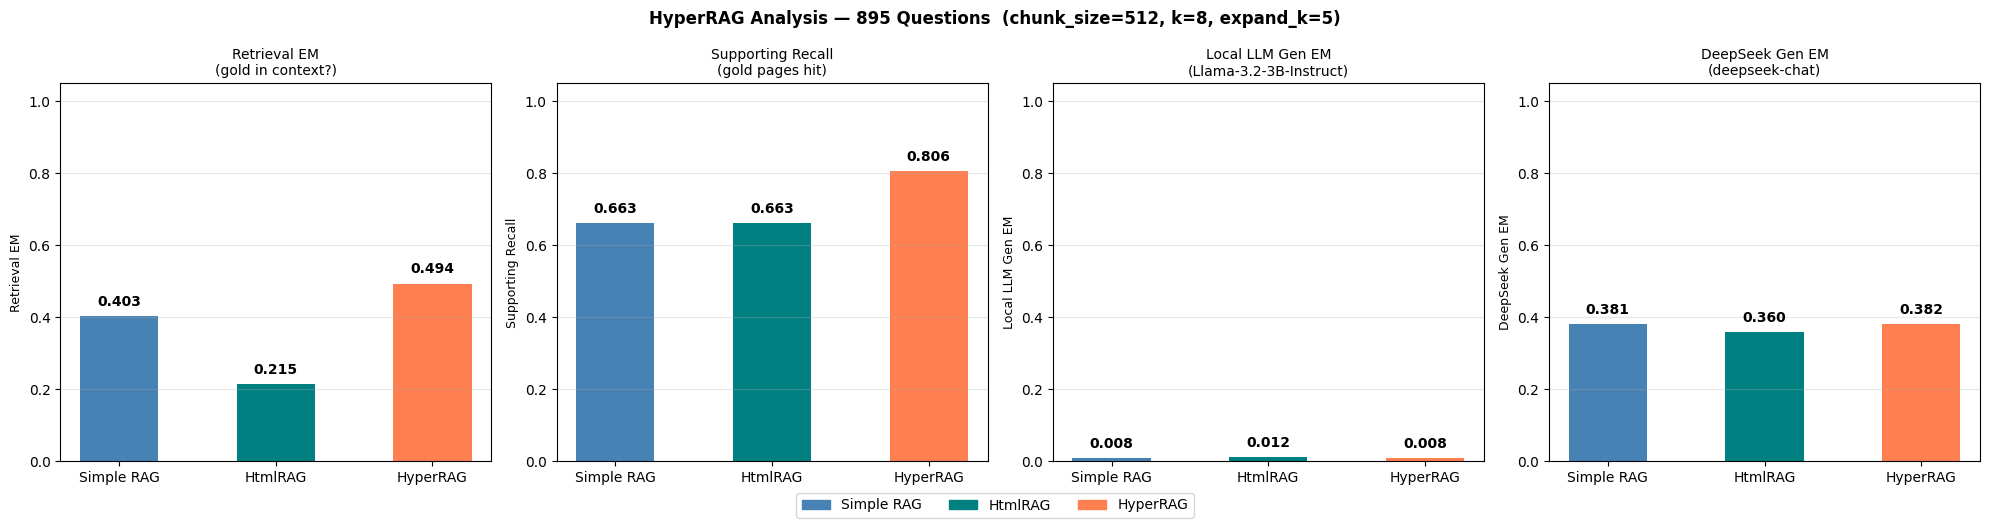

Chart saved  →  data\llm_analysis\comparison_chart.png


In [40]:
sys_names = list(SYSTEMS.keys())
colors    = {'Simple RAG': 'steelblue', 'HtmlRAG': 'teal', 'HyperRAG': 'coral'}
bar_colors = [colors[s] for s in sys_names]

local_label = LOCAL_MODEL.split('/')[-1] if USE_LOCAL_LLM else 'Local LLM'
ds_label    = DEEPSEEK_MODEL if USE_DEEPSEEK else 'DeepSeek'

metrics = [
    ('retrieval_em',      f'Retrieval EM\n(gold in context?)',        1.05),
    ('supporting_recall', f'Supporting Recall\n(gold pages hit)',     1.05),
    ('local_gen_em',      f'Local LLM Gen EM\n({local_label})',       1.05),
    ('ds_gen_em',         f'DeepSeek Gen EM\n({ds_label})',           1.05),
]

fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5))
fig.suptitle(
    f'HyperRAG Analysis — {len(subset)} Questions  '
    f'(chunk_size={CHUNK_SIZE}, k={K}, expand_k={EXPAND_K})',
    fontsize=12, fontweight='bold'
)

for ax, (metric, title, ylim) in zip(axes, metrics):
    vals = []
    for sn in sys_names:
        rows = [r for r in all_results if r['system'] == sn]
        v = mean_safe(rows, metric)
        vals.append(v if v is not None else 0.0)

    bars = ax.bar(sys_names, vals, color=bar_colors, width=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
                f'{h:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim(0, ylim)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(title.split('\n')[0], fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# Legend
handles = [mpatches.Patch(color=colors[s], label=s) for s in sys_names]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
chart_path = OUTPUT_DIR / 'comparison_chart.png'
plt.savefig(str(chart_path), dpi=130, bbox_inches='tight')
plt.show()
print(f'Chart saved  →  {chart_path}')

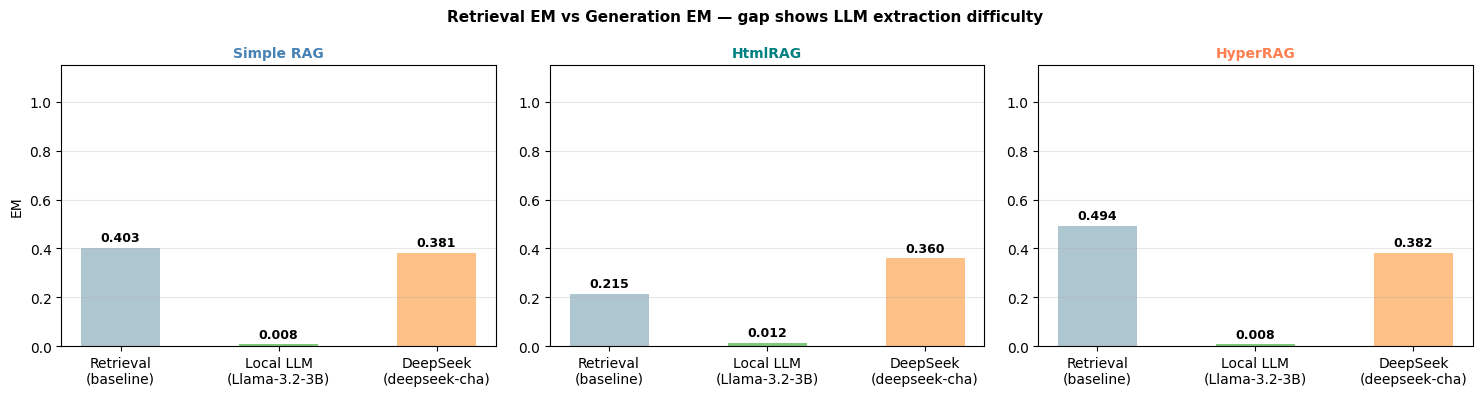

Chart saved  →  data\llm_analysis\retrieval_vs_generation.png


: 

In [ ]:
# ── Retrieval EM vs Generation EM comparison ─────────────────
# Shows the 'extraction gap': retrieval succeeds but LLM fails to extract

fig, axes = plt.subplots(1, len(SYSTEMS), figsize=(5 * len(SYSTEMS), 4), sharey=False)
fig.suptitle('Retrieval EM vs Generation EM — gap shows LLM extraction difficulty',
             fontsize=11, fontweight='bold')

for ax, sys_name in zip(axes, sys_names):
    rows      = [r for r in all_results if r['system'] == sys_name]
    ret_em    = np.mean([r['retrieval_em'] for r in rows])
    local_em  = mean_safe(rows, 'local_gen_em') or 0
    ds_em     = mean_safe(rows, 'ds_gen_em')    or 0

    labels = ['Retrieval\n(baseline)', f'Local LLM\n({local_label[:12]})', f'DeepSeek\n({ds_label[:12]})']
    vals   = [ret_em, local_em, ds_em]
    clrs   = ['#aec6cf', '#7fc97f', '#fdc086']

    bars = ax.bar(labels, vals, color=clrs, width=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.015,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(sys_name, fontsize=10, fontweight='bold', color=colors[sys_name])
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('EM' if sys_name == sys_names[0] else '')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
chart2_path = OUTPUT_DIR / 'retrieval_vs_generation.png'
plt.savefig(str(chart2_path), dpi=130, bbox_inches='tight')
plt.show()
print(f'Chart saved  →  {chart2_path}')

---
## Summary

### Output files

| File | Contents |
|------|----------|
| `data/llm_analysis/full_results.json` | Complete results with config, summary, all per-question rows (including chunk_details) |
| `data/llm_analysis/results_per_question.csv` | Flat table: one row per (question × system) |
| `data/llm_analysis/summary_by_system.csv` | Aggregate metrics: all + by subset type |
| `data/llm_analysis/chunk_details.csv` | Per-chunk breakdown: rank, score, gold?, answer? |
| `data/llm_analysis/comparison_chart.png` | 4-panel bar chart across systems |
| `data/llm_analysis/retrieval_vs_generation.png` | Extraction gap: retrieval EM vs gen EM |

### Key metrics explained

| Metric | Source | Question answered |
|--------|--------|---------|
| **Retrieval EM** | Pre-LLM | Is the gold answer physically present in the context? |
| **Supporting Recall** | Pre-LLM | Did we retrieve both gold supporting pages? |
| **Generation EM** | Local / DeepSeek | Did the LLM extract the correct short answer? |
| **Generation F1** | Local / DeepSeek | Word-overlap quality of the generated answer |

### Questions subset logic

- **`graph-wins`**: HyperRAG's graph expansion bridges the gap — Simple RAG misses, HyperRAG hits.  
  _Expected_: higher Retrieval EM for HyperRAG, similar for Simple RAG.

- **`both-pass`**: Both systems retrieve the answer. Graph expansion is neutral here.  
  _Expected_: all systems have similar Retrieval EM ≈ 1.0.

### Interpretation guide

```
Retrieval EM >> Generation EM  →  LLM extraction is the bottleneck
Retrieval EM  ≈ Generation EM  →  LLM works well when context is right
HyperRAG SR > Simple SR        →  graph expansion finds supporting pages
DeepSeek EM  >> Local EM       →  API model extracts better from noisy context
```